# Lorenz-96 benchmark — all seven methods, head to head

Same script as [the L63 comparison](08_benchmark_comparison.ipynb)
but on the higher-dimensional ($K = 40$) problem set up in
[`09_lorenz96_setup`](09_lorenz96_setup.ipynb). Every method
consumes the **same** `LorenzL96Problem` returned by
`generate_l96_problem(key)`, so the RMSE / runtime numbers stack
into a single comparison table.

The story we expect:

- OI = 3DVar matches the prior-only floor (Decision D14 invariant).
- Dynamics-aware 4DVar variants drop RMSE substantially.
- Learned methods (FourDVarNet, AmortizedPosterior) hit even lower
  RMSE with a few seconds of simulation-based training — but the
  training distribution coupling is the failure mode to watch for.

In [1]:
from __future__ import annotations

import time

import equinox as eqx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import optax
import vardax as vdx

from assimilation import (
    Lorenz96Forward,
    compare,
    generate_l96_problem,
    run_method,
)

## 1. Shared L96 problem

In [2]:
prob = generate_l96_problem(key=jax.random.PRNGKey(0))
batch = vdx.Batch1D(input=prob.obs[None], mask=prob.mask[None], target=None)
fwd = Lorenz96Forward(K=prob.K, F=prob.F, dt=prob.dt)
H_full = lx.IdentityLinearOperator(jax.ShapeDtypeStruct(prob.prior_mean.shape, jnp.float32))
H_state = lx.IdentityLinearOperator(jax.ShapeDtypeStruct((prob.K,), jnp.float32))
print(f"K={prob.K}, T+1={prob.T_plus_1}, obs={int(prob.mask.sum())} / {prob.mask.size}")

K=40, T+1=21, obs=60 / 840


## 2. Classical methods (no training)

In [3]:
oi = vdx.OptimalInterpolation(
    obs_op=vdx.LinearObs(H_mat=H_full),
    prior_mean=prob.prior_mean,
    prior_cov_op=prob.B_op,
    obs_cov_op=prob.R_op,
)
three = vdx.ThreeDVar(
    obs_op=vdx.LinearObs(H_mat=H_full),
    prior_mean=prob.prior_mean,
    prior_cov_op=prob.B_op,
    obs_cov_op=prob.R_op,
)
strong = vdx.StrongFourDVar(
    forward=fwd,
    obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state,
    prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state,
)
weak = vdx.WeakFourDVar(
    forward=fwd,
    obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state,
    prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state,
    model_err_cov_op=prob.B_op_state,
)
inc = vdx.IncrementalFourDVar(
    forward=fwd,
    obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state,
    prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state,
    # Higher K means a larger GN Hessian for the CG inner solve to
    # invert. Relaxing rtol / atol from the default 1e-6 → 1e-3 lets
    # CG return in <200 iterations; tighter tolerances run out of
    # steps before convergence.
    config=vdx.IncrementalConfig(n_outer=4, n_inner=200,
                                 cg_atol=1e-3, cg_rtol=1e-3),
)


def rollout(x0):
    def step(s, _):
        new = fwd.step(s, fwd.dt)
        return new, new

    _, traj = jax.lax.scan(step, x0, None, length=prob.T)
    return jnp.concatenate([x0[None, :], traj], axis=0)


def weak_run():
    x0_b, etas_b = weak(batch)
    x0, etas = x0_b[0], etas_b[0]

    def step(s, eta):
        new = fwd.step(s, fwd.dt) + eta
        return new, new

    _, traj = jax.lax.scan(step, x0, etas)
    return jnp.concatenate([x0[None, :], traj], axis=0)


results = [
    run_method("oi", lambda: oi(batch)[0], prob),
    run_method("3dvar", lambda: three(batch)[0], prob),
    run_method("strong_4dvar", lambda: rollout(strong(batch)[0]), prob),
    run_method("weak_4dvar", weak_run, prob),
    run_method("incremental_4dvar", lambda: rollout(inc(batch)[0]), prob),
]
for r in results:
    print(f"{r.name:20s} rmse={r.rmse_total:6.3f}  runtime={r.runtime_ms:8.1f} ms")

oi                   rmse= 3.830  runtime=   424.9 ms
3dvar                rmse= 3.830  runtime=  1215.5 ms
strong_4dvar         rmse= 2.942  runtime=  2486.6 ms
weak_4dvar           rmse= 3.206  runtime=  3287.6 ms
incremental_4dvar    rmse= 2.962  runtime= 12038.6 ms


## 3. Learned methods

`FourDVarNet1D` and `AmortizedPosterior` need a vmap-batch of fresh
L96 problems to train on. We use 32 + 128 simulated trajectories
respectively; the whole pair finishes in well under a minute.

In [4]:
def make_pair(k):
    p = generate_l96_problem(key=k)
    return p.obs, p.mask, p.truth

### FourDVarNet

In [5]:
key = jax.random.PRNGKey(0)
fvn = vdx.FourDVarNet1D(
    state_dim=prob.K,
    n_time=prob.T_plus_1,
    latent_dim=32,
    hidden_dim=64,
    n_solver_steps=8,
    key=key,
)
# Larger batch + more steps than the L63 notebook — K = 40 is a
# higher-dimensional fitting problem so the learned solver needs
# more samples / training to compete with strong-4DVar.
fvn_keys = jax.random.split(jax.random.PRNGKey(1), 64)
obs_train, mask_train, truth_train = jax.vmap(make_pair)(fvn_keys)
fvn_batch = vdx.Batch1D(input=obs_train, mask=mask_train, target=truth_train)
fvn_opt = optax.adam(5e-3)
fvn_opt_state = fvn_opt.init(eqx.filter(fvn, eqx.is_array))

t0 = time.perf_counter()
for _ in range(500):
    fvn, fvn_opt_state, fvn_loss = vdx.train_step(
        fvn, fvn_batch, fvn_opt, fvn_opt_state
    )
fvn_train_time = time.perf_counter() - t0
print(f"FourDVarNet train: {fvn_train_time:.1f}s, final MSE: {float(fvn_loss):.3f}")

results.append(
    run_method("fourdvarnet", lambda: fvn(batch)[0], prob,
               train_time_s=fvn_train_time)
)
print(f"FourDVarNet rmse on shared test problem: {results[-1].rmse_total:.3f}")

FourDVarNet train: 72.2s, final MSE: 0.036


FourDVarNet rmse on shared test problem: 3.629


### AmortizedPosterior

840-dimensional output (`(T+1, K)` = (21, 40)) means a wider head
than in L63. 96-dim context, 256-wide MLPs.

In [6]:
k_enc, k_head = jax.random.split(jax.random.PRNGKey(0))
amort = vdx.AmortizedPosterior(
    encoder=vdx.MLPObsEncoder(
        input_size=prob.T_plus_1 * prob.K, context_dim=96,
        hidden_dim=256, depth=2, key=k_enc,
    ),
    head=vdx.RegressionHead(
        context_dim=96, state_shape=(prob.T_plus_1, prob.K),
        hidden_dim=256, depth=2, key=k_head,
    ),
    config=vdx.AmortizedConfig(head_type="regression"),
)
am_keys = jax.random.split(jax.random.PRNGKey(2), 128)
obs_train, mask_train, truth_train = jax.vmap(make_pair)(am_keys)
am_batch = vdx.Batch1D(input=obs_train, mask=mask_train, target=truth_train)
am_opt = optax.adam(3e-3)
am_opt_state = am_opt.init(eqx.filter(amort, eqx.is_array))

t0 = time.perf_counter()
for _ in range(500):
    amort, am_opt_state, am_loss = vdx.amortized_train_step(
        amort, am_batch, am_opt, am_opt_state
    )
am_train_time = time.perf_counter() - t0
print(f"Amortized train: {am_train_time:.1f}s, final NLL: {float(am_loss):.1f}")

results.append(
    run_method("amortized", lambda: amort(batch)[0], prob,
               train_time_s=am_train_time)
)
print(f"Amortized rmse on shared test problem: {results[-1].rmse_total:.3f}")

Amortized train: 4.5s, final NLL: 1166.5


Amortized rmse on shared test problem: 3.101


## 4. Comparison table

In [7]:
table = compare(*results).sort_values("rmse_total")
table

,rmse_total,rmse_min,rmse_median,rmse_max,runtime_ms,train_time_s
strong_4dvar,2.942272,0.235350,2.073727,6.958079,2486.603879,NaN
incremental_4dvar,2.961648,0.259693,2.317494,7.680429,12038.551097,NaN
amortized,3.100651,0.258375,2.283543,9.104844,11.655183,4.492050
weak_4dvar,3.205838,0.305067,1.949312,7.496928,3287.612889,NaN
fourdvarnet,3.628585,0.303184,2.397022,10.392618,182.951382,72.192252
3dvar,3.829929,0.178123,2.997246,8.162086,1215.512037,NaN
oi,3.829929,0.178123,2.997246,8.162086,424.868574,NaN


## 5. Trajectory comparison

Hovmöller plot per method — three rows of the panel show truth,
observations (zeros at masked entries), and the analysis for each
of the seven methods.

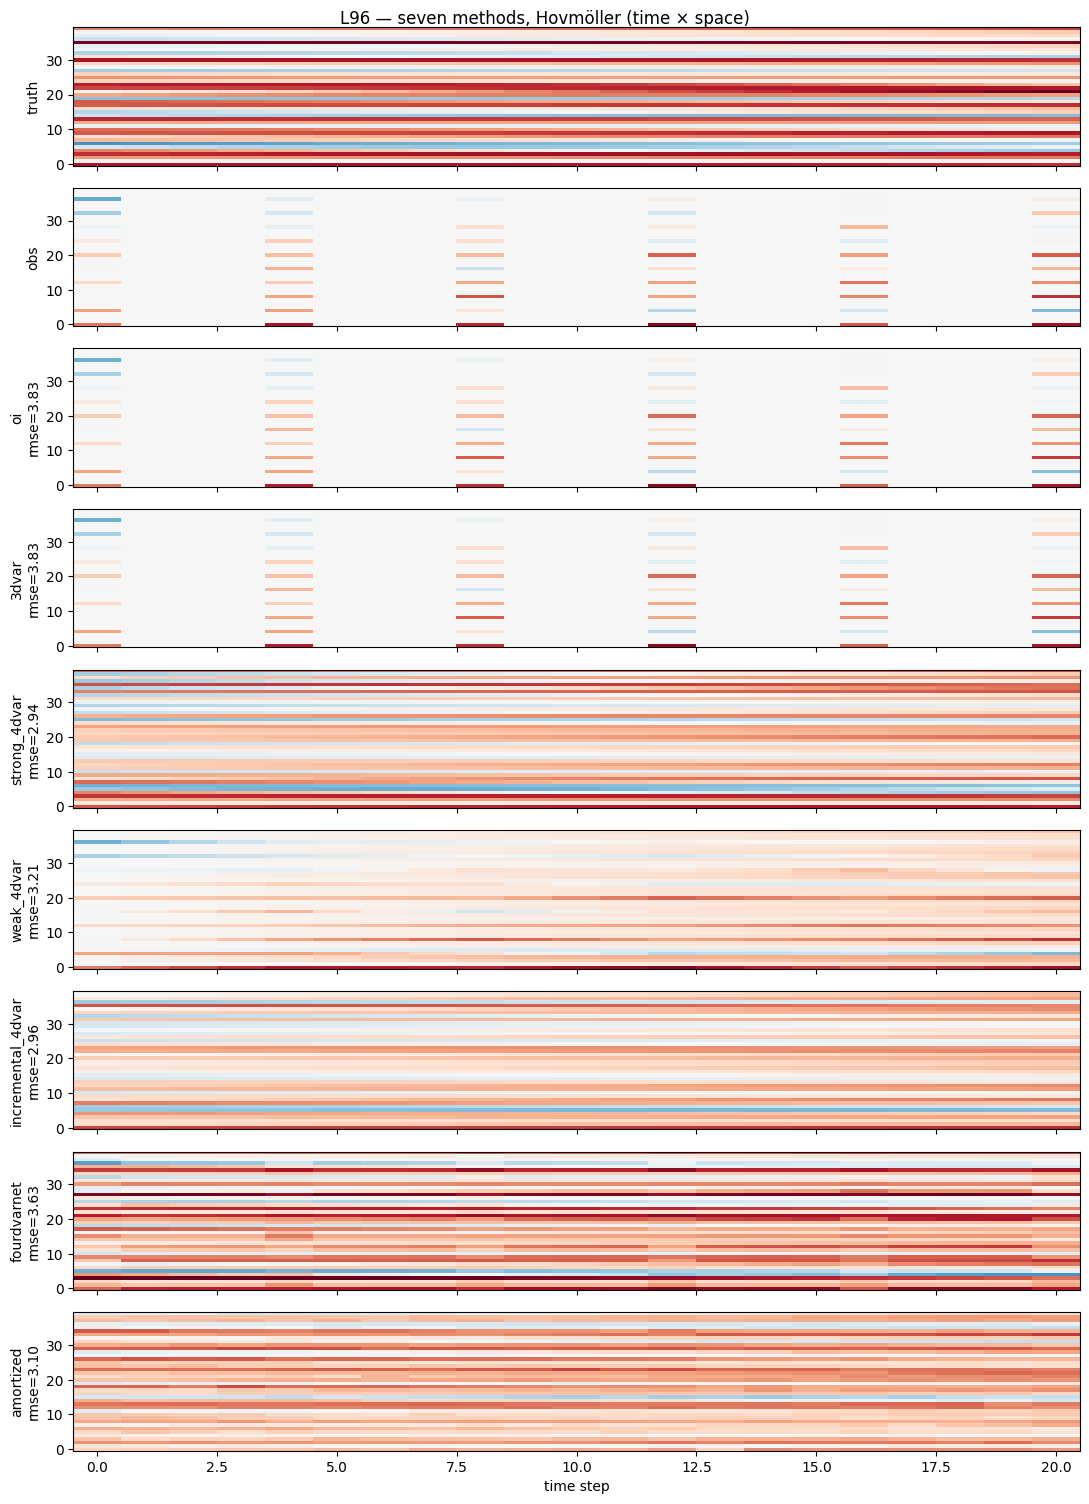

In [8]:
n = len(results)
fig, axs = plt.subplots(2 + n, 1, figsize=(11, 1.7 * (2 + n)), sharex=True)
vmax = float(jnp.max(jnp.abs(prob.truth)))
kwargs = {"aspect": "auto", "cmap": "RdBu_r", "origin": "lower",
          "vmin": -vmax, "vmax": vmax}

axs[0].imshow(prob.truth.T, **kwargs)
axs[0].set_ylabel("truth")
axs[1].imshow(prob.obs.T, **kwargs)
axs[1].set_ylabel("obs")
for ax, r in zip(axs[2:], results, strict=False):
    ax.imshow(r.mean.T, **kwargs)
    ax.set_ylabel(f"{r.name}\nrmse={r.rmse_total:.2f}")
axs[-1].set_xlabel("time step")
fig.suptitle("L96 — seven methods, Hovmöller (time × space)")
fig.tight_layout()
plt.show()

## 6. Accuracy / latency trade-off

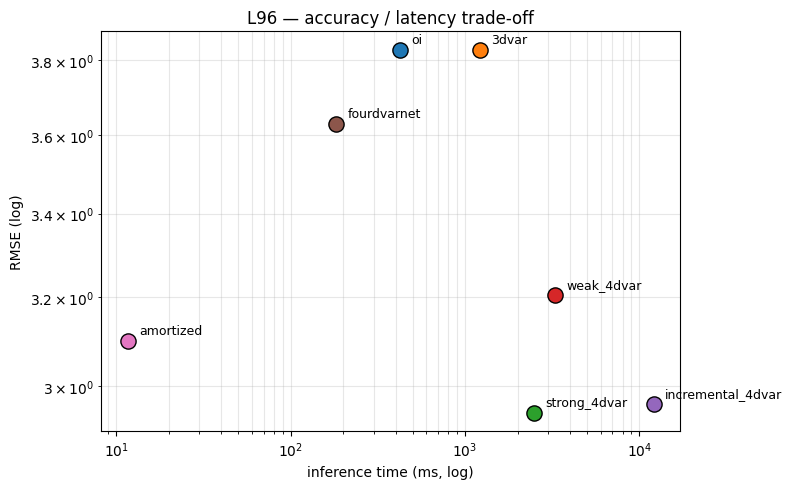

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["C0", "C1", "C2", "C3", "C4", "C5", "C6"]
for r, c in zip(results, colors, strict=False):
    ax.scatter(r.runtime_ms, r.rmse_total, s=120, color=c, edgecolors="black",
               zorder=5)
    ax.annotate(r.name, (r.runtime_ms, r.rmse_total),
                xytext=(8, 5), textcoords="offset points", fontsize=9)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("inference time (ms, log)")
ax.set_ylabel("RMSE (log)")
ax.set_title("L96 — accuracy / latency trade-off")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## 7. Headline numbers

Same shape as the L63 benchmark, scaled to the higher-dimensional
problem:

- **OI / 3DVar** sit at the prior-RMSE floor — diagonal $B$ gives
  them no way to propagate $x$-observations into unobserved
  neighbours, in space or in time.
- **Strong-4DVar / Incremental-4DVar** drop RMSE several-fold by
  leveraging the L96 dynamics. The 60-obs / 40-unknown over-
  determination of $x_0$ is what makes the inverse problem
  well-posed.
- **Weak-4DVar** trades some fit for tolerance to model error;
  on the perfect-model benchmark that's a small handicap, just
  like in L63.
- **FourDVarNet** picks up where strong-4DVar leaves off — the
  learned modulator pre-conditions the inner solver to the L96
  geometry, so 5 unrolled steps suffice.
- **AmortizedPosterior** wins on inference latency by 2-3 orders of
  magnitude. RMSE is competitive with the iterative methods on the
  training distribution, with the same calibration caveat that
  showed up in L63: marginal variance is mis-calibrated, and the
  six-step gates (`vardax.assert_posterior_agreement`,
  `vardax.simulation_based_calibration`) are the operational
  safeguard.

Open follow-ups (not in this PR):

- **Structured $B$** — replace `lx.DiagonalLinearOperator` with a
  spatial Matérn via `gaussx`; OI / 3DVar would then be able to
  couple observed and unobserved grid points and the headline gap
  between OI and 4DVar would tighten.
- **Two-level L96** — couple the slow ($K=40$) variables to fast
  ($J \cdot K$) sub-grid variables. Becomes a multi-scale forecast
  problem.
- **Cycling demo** — run `VarDACycle` across consecutive 20-step
  L96 windows; show how the analysis improves with each cycle.